<a href="https://colab.research.google.com/github/drakopablo/eml_k_bandit_grupo17/blob/yolanda/egreedy_YOL2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos en un problema de k-armed bandit

*Description:* El experimento compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit.
Se generan gráficas de recompensas promedio para cada algoritmo.

    Author: Luis Daniel Hernández Molinero
    Email: ldaniel@um.es
    Date: 2025/01/29

This software is licensed under the GNU General Public License v3.0 (GPL-3.0),
with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html



## Preparación del entorno


In [ ]:
#@title Copiar el repositorio.

!git clone https://github.com/ldaniel-hm/eml_k_bandit.git
!cd eml_k_bandit/

Cloning into 'eml_k_bandit'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 70 (delta 31), reused 40 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (70/70), 319.50 KiB | 5.60 MiB/s, done.
Resolving deltas: 100% (31/31), done.


In [ ]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
sys.path.append('/content/eml_k_bandit')


# Verificar que se han añadido correctamente
print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy
from arms import ArmNormal, Bandit
from plotting import plot_average_rewards, plot_optimal_selections


['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/eml_k_bandit']


## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio.

Por ejemplo. Dado un bandido de k-brazos, se ejecutan dos algoritmos epsilon-greedy con diferentes valores de epsilon. Se estudia la evolución de cada política  en un número de pasos, por ejemplo, mil pasos. Entonces se repite el experimento un número de veces, por ejemplo, 500 veces. Es decir, se ejecutan 500 veces la evolución de cada algoritmo en 1000 pasos. Para cada paso calculamos el promedio de las recoponensas obtenidas en esas 500 veces.

In [ ]:

def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                #TODO: modificar optimal_selections cuando el brazo elegido se corresponda con el brazo óptimo optimal_arm


    rewards /= runs

    # TODO: calcular el porcentaje de selecciones óptimas y almacenar en optimal_selections

    return rewards, optimal_selections


## Ejecución del experimento

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución gaussina con desviación 1. Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 3 algoritmos epsilon greedy para valores epsilon: 0.0, 0.01, y 0.1.

In [ ]:

# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


## Visualización de los resultados

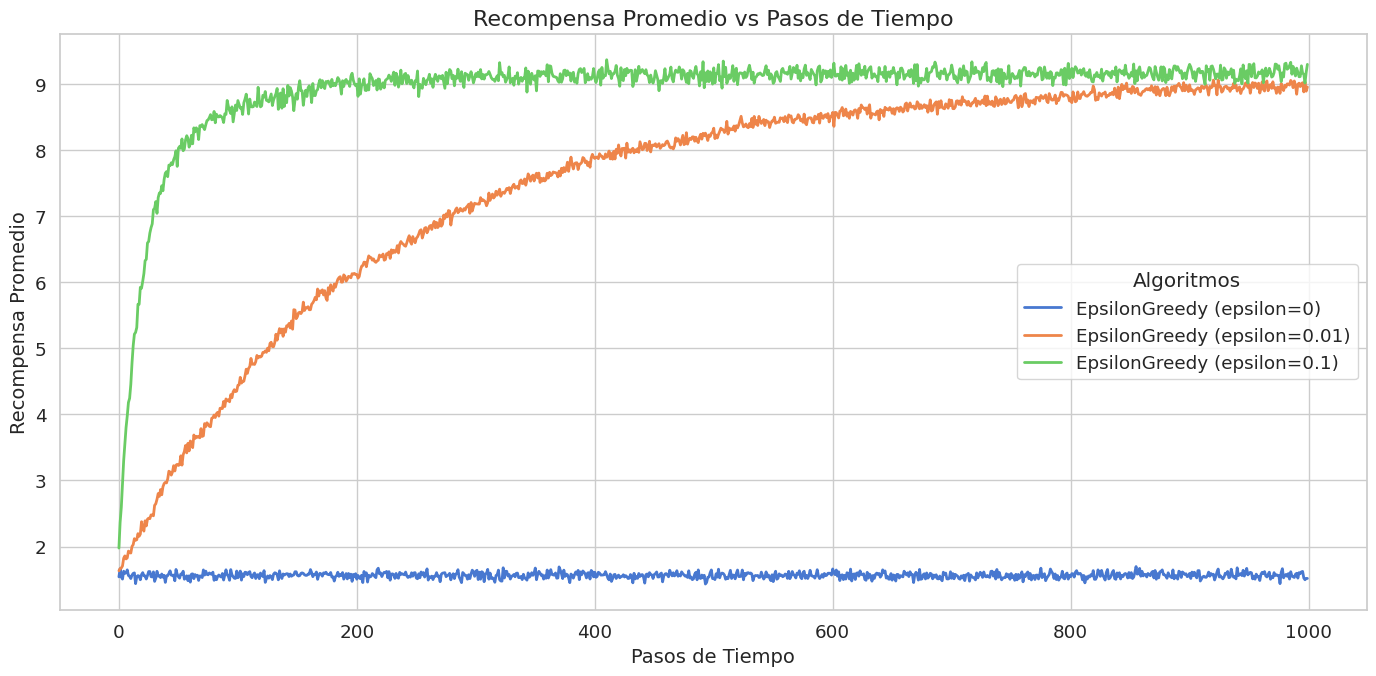

In [ ]:

# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
# plot_optimal_selections(steps, optimal_selections, algorithms)


### Análisis detallado de la imagen

La imagen muestra un gráfico de líneas titulado **"Recompensa Promedio vs Pasos de Tiempo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **ε-Greedy** en un entorno de multi-armed bandit. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra la **recompensa promedio** obtenida por cada algoritmo.


1. **Tres líneas de colores distintos representan diferentes valores de ε en el algoritmo ε-Greedy:**
   - **Azul (ε = 0):** Representa una estrategia completamente **explotadora**, es decir, que siempre elige la acción que ha dado la mejor recompensa hasta ahora sin explorar nuevas opciones.
   - **Naranja (ε = 0.01):** Representa una estrategia con una pequeña probabilidad del 1% de elegir una acción aleatoria (exploración).
   - **Verde (ε = 0.1):** Representa una estrategia con un 10% de probabilidad de explorar acciones aleatorias.

2. **Crecimiento de la recompensa promedio:**
   - La línea **verde (ε=0.1)** alcanza rápidamente una recompensa promedio alta, lo que indica que la estrategia con mayor exploración aprende más rápido qué brazos del bandit son óptimos.
   - La línea **naranja (ε=0.01)** también muestra un crecimiento, pero más lento en comparación con ε=0.1.
   - La línea **azul (ε=0)** se mantiene en un nivel bajo de recompensa, lo que sugiere que no logra encontrar el mejor brazo porque no explora nuevas opciones.

---





## Conclusiones

Hemos estudiado un  **experimento de toma de decisiones secuenciales**, modelado con un **Multi-Armed Bandit (MAB)**. Este problema es fundamental en el aprendizaje por refuerzo y la teoría de decisiones. La idea principal es que un agente debe aprender cuál es la mejor acción (brazo del bandit) a partir de la experiencia acumulada. Para este estudio nos hemos centrado solo en el estudio del algoritmo epsilon-greedy, llegando a las siguientes conclusiones a partir de los resultados obtenidos y la gráfica generada:

#### **1. Exploración vs Explotación**
El algoritmo **ε-Greedy** equilibra la exploración y la explotación:
- **Explotación (ε=0)**: Siempre elige la mejor opción conocida, pero si inicialmente se selecciona un brazo subóptimo, nunca descubrirá otras opciones más rentables.
- **Exploración (ε>0)**: Introduce aleatoriedad en la selección de acciones para descubrir nuevas opciones potencialmente mejores.

El gráfico confirma este comportamiento:
- **ε=0.1 (verde)** obtiene la mejor recompensa promedio a lo largo del tiempo porque explora lo suficiente como para encontrar rápidamente el mejor brazo.
- **ε=0.01 (naranja)** explora menos, por lo que tarda más en converger a una recompensa alta.
- **ε=0 (azul)** no explora en absoluto y queda atrapado en una recompensa subóptima.

#### **2. Convergencia de los algoritmos**
Los algoritmos con mayor exploración (ε=0.1) alcanzan una recompensa alta más rápido. Esto se debe a que:
- Al principio, el algoritmo **no tiene información suficiente** sobre cuál es el mejor brazo.
- Con el tiempo, al realizar exploraciones, descubre cuál es el mejor brazo y empieza a explotarlo más.
- Un **balance entre exploración y explotación** es clave para maximizar la recompensa a largo plazo.


#### **3. Aplicaciones y conclusiones**
- En problemas de toma de decisiones **(ejemplo: recomendaciones, optimización de anuncios, medicina personalizada)**, una estrategia de exploración moderada como **ε=0.1** es más efectiva para encontrar la mejor opción rápidamente.
- **La falta de exploración (ε=0)** lleva a un desempeño deficiente, ya que el agente puede quedarse atrapado en una elección subóptima.

En conclusión, **el gráfico muestra cómo un nivel adecuado de exploración mejora significativamente el rendimiento del algoritmo en un entorno de aprendizaje por refuerzo**. 🚀

Module: algorithms/epsilon_greedy.py
Description: Implementación del algoritmo epsilon-greedy para el problema de los k-brazos.

Author: Luis Daniel Hernández Molinero
Email: ldaniel@um.es
Date: 2025/01/29

This software is licensed under the GNU General Public License v3.0 (GPL-3.0),
with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html

Sólo realiza explotaciones y no hace ningún intetno de explorar.

Exploración → probar opciones para aprender.

Explotación → elegir la mejor opción conocida hasta ahora.

Problema: puede quedarse atrapado en una mala opción si la estimación inicial es engañosa.

Estudie los algoritmos -greedy, UCB1 y Softmax usando los siguiente tipos de bandidos.

◦ Distribución Bernoulli. Cada brazo solo puede dar dos resultados: éxito, 1, o fracaso, 0.

◦ Distribución Binomial. A cada brazo se le asocia una distribución B(n, p).

◦ Distribución Normal. Cada brazo sigue una N (µ, σ2
).

In [ ]:
"""
Module: algorithms/epsilon_greedy.py
Description: Implementación del algoritmo epsilon-greedy para el problema de los k-brazos.

Author: Luis Daniel Hernández Molinero
Email: ldaniel@um.es
Date: 2025/01/29

This software is licensed under the GNU General Public License v3.0 (GPL-3.0),
with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html
"""

import numpy as np

from algorithms.algorithm import Algorithm

class EpsilonGreedy(Algorithm):

    def __init__(self, k: int, epsilon: float = 0.1):
        """
        Inicializa el algoritmo epsilon-greedy.

        :param k: Número de brazos.
        :param epsilon: Probabilidad de exploración (seleccionar un brazo al azar).
        :raises ValueError: Si epsilon no está en [0, 1].
        """
        assert 0 <= epsilon <= 1, "El parámetro epsilon debe estar entre 0 y 1."

        super().__init__(k)
        self.epsilon = epsilon

    def select_arm(self) -> int:
        """
        Selecciona un brazo basado en la política epsilon-greedy.

        :return: índice del brazo seleccionado.
        """

        # Observa que para para epsilon=0 solo selecciona un brazo y no hace un primer recorrido por todos ellos.
        # ¿Podrías modificar el código para que funcione correctamente para epsilon=0?

        if np.random.random() < self.epsilon:
            # Selecciona un brazo al azar
            chosen_arm = np.random.choice(self.k)
        else:
            # Selecciona el brazo con la recompensa promedio estimada más alta
            chosen_arm = np.argmax(self.values)

        return chosen_arm

In [2]:
!git clone -b yolanda https://github.com/drakopablo/eml_k_bandit_grupo17.git

Cloning into 'eml_k_bandit_grupo17'...
remote: Enumerating objects: 114, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 114 (delta 52), reused 66 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (114/114), 2.75 MiB | 2.71 MiB/s, done.
Resolving deltas: 100% (52/52), done.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
Distribución Normal. Cada brazo sigue una N (µ, σ2 ).

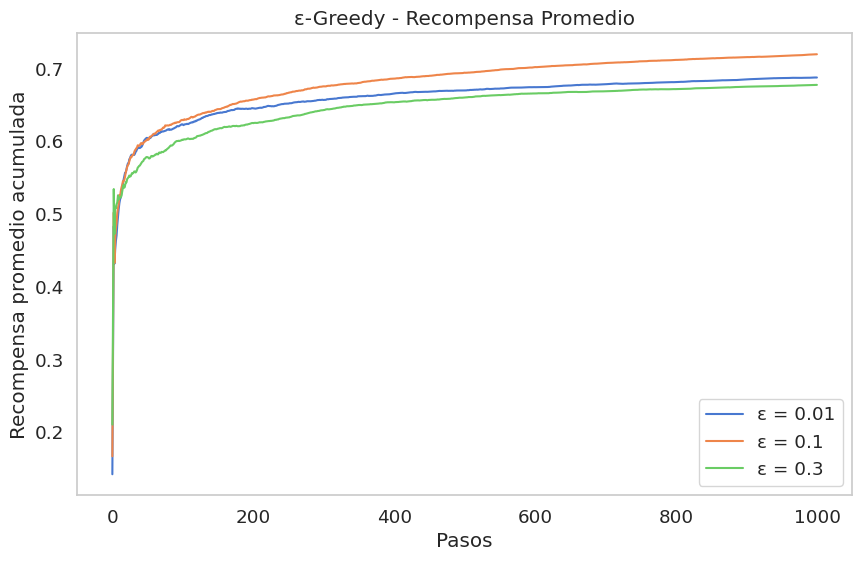

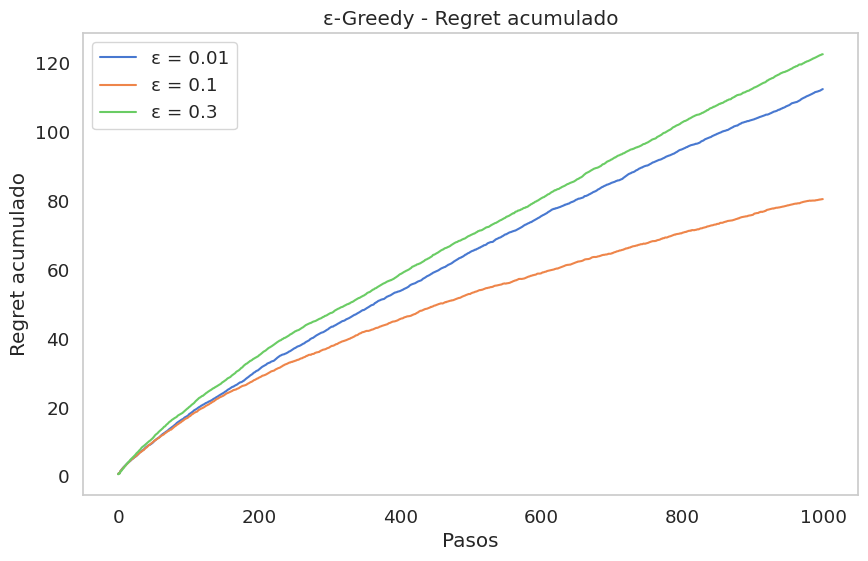

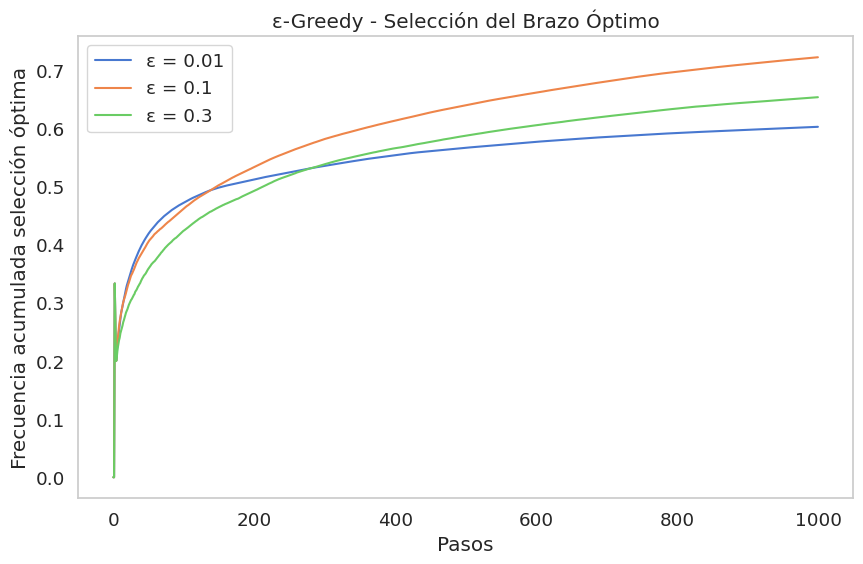

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1️⃣ ENTORNO normal R∼N(μi​,σ2) R∈(−∞,+∞)
# ==============================

class GaussianBandit:
    def __init__(self, means, std=1):
        self.means = np.array(means)
        self.k = len(means)
        self.std = std
        self.optimal_arm = np.argmax(self.means)
        self.optimal_mean = np.max(self.means)

    def pull(self, arm):
        return np.random.normal(self.means[arm], self.std)


# ==============================
# 2️⃣ CLASE BASE
# ==============================

class Algorithm:
    def __init__(self, k):
        self.k = k
        self.counts = np.zeros(k)
        self.values = np.zeros(k)

    def update(self, chosen_arm, reward):
        self.counts[chosen_arm] += 1
        n = self.counts[chosen_arm]
        value = self.values[chosen_arm]
        self.values[chosen_arm] += (reward - value) / n


# ==============================
# 3️⃣ EPSILON-GREEDY
# ==============================

class EpsilonGreedy(Algorithm):

    def __init__(self, k, epsilon=0.1):
        assert 0 <= epsilon <= 1
        super().__init__(k)
        self.epsilon = epsilon

    def select_arm(self):
        # Forzar probar cada brazo al menos una vez
        for arm in range(self.k):
            if self.counts[arm] == 0:
                return arm

        if np.random.random() < self.epsilon:
            return np.random.choice(self.k)
        else:
            return np.argmax(self.values)


# ==============================
# 4️⃣ SIMULACIÓN
# ==============================

def run_experiment(algorithms, bandit, steps=1000, simulations=500):

    n_algorithms = len(algorithms)

    rewards = np.zeros((n_algorithms, steps))
    optimal_selections = np.zeros((n_algorithms, steps))
    regret = np.zeros((n_algorithms, steps))

    for s in range(simulations):

        alg_instances = [type(algo)(bandit.k, algo.epsilon) for algo in algorithms]

        for i, algo in enumerate(alg_instances):

            for t in range(steps):
                arm = algo.select_arm()
                reward = bandit.pull(arm)
                algo.update(arm, reward)

                rewards[i, t] += reward
                regret[i, t] += bandit.optimal_mean - reward

                if arm == bandit.optimal_arm:
                    optimal_selections[i, t] += 1

    # Promediar resultados
    rewards /= simulations
    regret /= simulations
    optimal_selections /= simulations

    return rewards, regret, optimal_selections


# ==============================
# 5️⃣ PARÁMETROS
# ==============================

k = 5
means = [0.2, 0.5, 0.8, 0.3, 0.6]   # brazo óptimo = índice 2
std = 1
steps = 1000
simulations = 500

bandit = GaussianBandit(means, std)

algorithms = [
    EpsilonGreedy(k, epsilon=0.01),
    EpsilonGreedy(k, epsilon=0.1),
    EpsilonGreedy(k, epsilon=0.3),
]

labels = ["ε = 0.01", "ε = 0.1", "ε = 0.3"]

rewards, regret, optimal_selections = run_experiment(
    algorithms, bandit, steps, simulations
)


# ==============================
# 6️⃣ GRÁFICAS
# ==============================

# 🔹 Recompensa promedio acumulada
plt.figure(figsize=(10,6))
for i in range(len(algorithms)):
    avg_reward = np.cumsum(rewards[i]) / np.arange(1, steps+1)
    plt.plot(avg_reward, label=labels[i])

plt.xlabel("Pasos")
plt.ylabel("Recompensa promedio acumulada")
plt.title("ε-Greedy - Recompensa Promedio")
plt.legend()
plt.grid()
plt.show()


# 🔹 Regret acumulado
plt.figure(figsize=(10,6))
for i in range(len(algorithms)):
    cumulative_regret = np.cumsum(regret[i])
    plt.plot(cumulative_regret, label=labels[i])

plt.xlabel("Pasos")
plt.ylabel("Regret acumulado")
plt.title("ε-Greedy - Regret acumulado")
plt.legend()
plt.grid()
plt.show()


# 🔹 Porcentaje selección brazo óptimo
plt.figure(figsize=(10,6))
for i in range(len(algorithms)):
    optimal_rate = np.cumsum(optimal_selections[i]) / np.arange(1, steps+1)
    plt.plot(optimal_rate, label=labels[i])

plt.xlabel("Pasos")
plt.ylabel("Frecuencia acumulada selección óptima")
plt.title("ε-Greedy - Selección del Brazo Óptimo")
plt.legend()
plt.grid()
plt.show()

◦ Distribución Bernoulli. Cada brazo solo puede dar dos resultados: éxito, 1, o fracaso, 0.


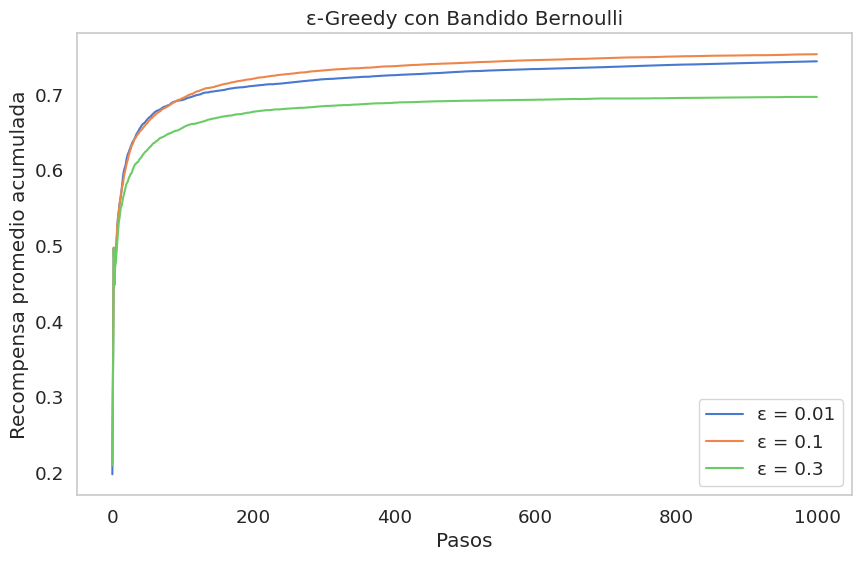

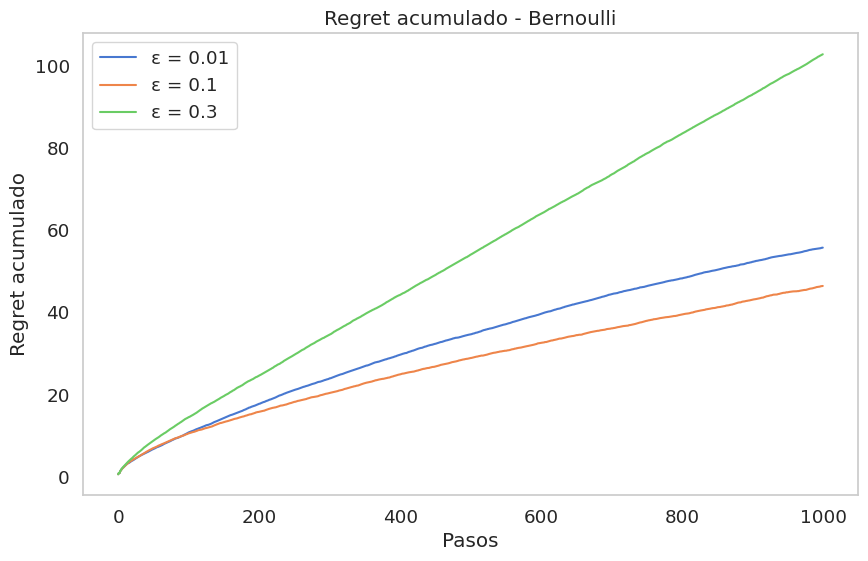

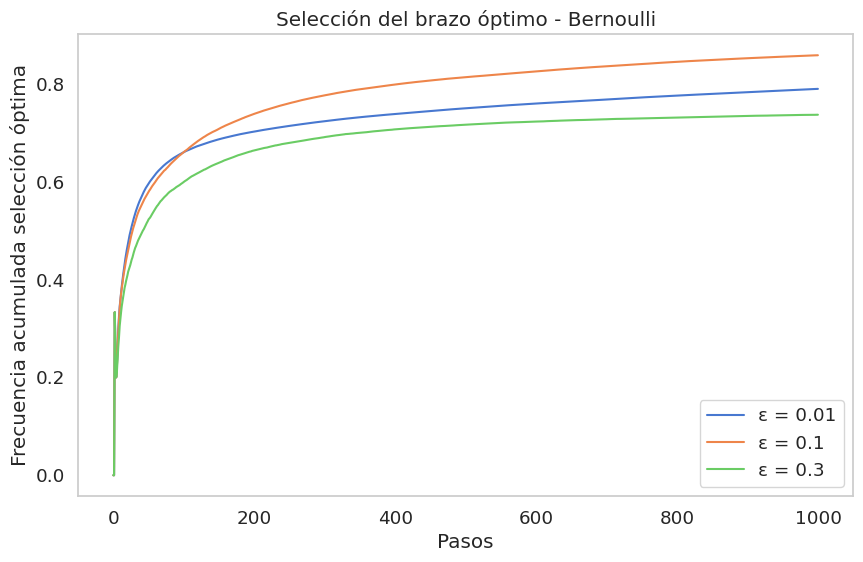

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1️⃣ ENTORNO BERNOULLI R∈{0,1}
# ==============================

class BernoulliBandit:
    def __init__(self, probabilities):
        self.probabilities = np.array(probabilities)
        self.k = len(probabilities)
        self.optimal_arm = np.argmax(self.probabilities)
        self.optimal_mean = np.max(self.probabilities)

    def pull(self, arm):
        return np.random.binomial(1, self.probabilities[arm])


# ==============================
# 2️⃣ CLASE BASE
# ==============================

class Algorithm:
    def __init__(self, k):
        self.k = k
        self.counts = np.zeros(k)
        self.values = np.zeros(k)

    def update(self, chosen_arm, reward):
        self.counts[chosen_arm] += 1
        n = self.counts[chosen_arm]
        value = self.values[chosen_arm]
        self.values[chosen_arm] += (reward - value) / n


# ==============================
# 3️⃣ EPSILON-GREEDY
# ==============================

class EpsilonGreedy(Algorithm):

    def __init__(self, k, epsilon=0.1):
        assert 0 <= epsilon <= 1
        super().__init__(k)
        self.epsilon = epsilon

    def select_arm(self):
        # Forzar que cada brazo se pruebe al menos una vez
        for arm in range(self.k):
            if self.counts[arm] == 0:
                return arm

        if np.random.random() < self.epsilon:
            return np.random.choice(self.k)
        else:
            return np.argmax(self.values)


# ==============================
# 4️⃣ SIMULACIÓN
# ==============================

def run_experiment(algorithms, bandit, steps=1000, simulations=500):

    n_algorithms = len(algorithms)

    rewards = np.zeros((n_algorithms, steps))
    regret = np.zeros((n_algorithms, steps))
    optimal_selections = np.zeros((n_algorithms, steps))

    for s in range(simulations):

        alg_instances = [type(algo)(bandit.k, algo.epsilon) for algo in algorithms]

        for i, algo in enumerate(alg_instances):

            for t in range(steps):
                arm = algo.select_arm()
                reward = bandit.pull(arm)
                algo.update(arm, reward)

                rewards[i, t] += reward
                regret[i, t] += bandit.optimal_mean - reward

                if arm == bandit.optimal_arm:
                    optimal_selections[i, t] += 1

    rewards /= simulations
    regret /= simulations
    optimal_selections /= simulations

    return rewards, regret, optimal_selections


# ==============================
# 5️⃣ PARÁMETROS
# ==============================

k = 5
probabilities = [0.2, 0.5, 0.8, 0.3, 0.6]  # brazo óptimo = índice 2
steps = 1000
simulations = 500

bandit = BernoulliBandit(probabilities)

algorithms = [
    EpsilonGreedy(k, epsilon=0.01),
    EpsilonGreedy(k, epsilon=0.1),
    EpsilonGreedy(k, epsilon=0.3),
]

labels = ["ε = 0.01", "ε = 0.1", "ε = 0.3"]

rewards, regret, optimal_selections = run_experiment(
    algorithms, bandit, steps, simulations
)


# ==============================
# 6️⃣ GRÁFICAS
# ==============================

# 🔹 Recompensa promedio acumulada
plt.figure(figsize=(10,6))
for i in range(len(algorithms)):
    avg_reward = np.cumsum(rewards[i]) / np.arange(1, steps+1)
    plt.plot(avg_reward, label=labels[i])

plt.xlabel("Pasos")
plt.ylabel("Recompensa promedio acumulada")
plt.title("ε-Greedy con Bandido Bernoulli")
plt.legend()
plt.grid()
plt.show()


# 🔹 Regret acumulado
plt.figure(figsize=(10,6))
for i in range(len(algorithms)):
    cumulative_regret = np.cumsum(regret[i])
    plt.plot(cumulative_regret, label=labels[i])

plt.xlabel("Pasos")
plt.ylabel("Regret acumulado")
plt.title("Regret acumulado - Bernoulli")
plt.legend()
plt.grid()
plt.show()


# 🔹 Frecuencia selección óptima
plt.figure(figsize=(10,6))
for i in range(len(algorithms)):
    optimal_rate = np.cumsum(optimal_selections[i]) / np.arange(1, steps+1)
    plt.plot(optimal_rate, label=labels[i])

plt.xlabel("Pasos")
plt.ylabel("Frecuencia acumulada selección óptima")
plt.title("Selección del brazo óptimo - Bernoulli")
plt.legend()
plt.grid()
plt.show()

Distribución Binomial. A cada brazo se le asocia una distribución B(n, p).Cada brazo devuelve un número entero entre:

0, 1,2,…,𝑛

Es como hacer n ensayos Bernoulli cada vez que tiras del brazo.

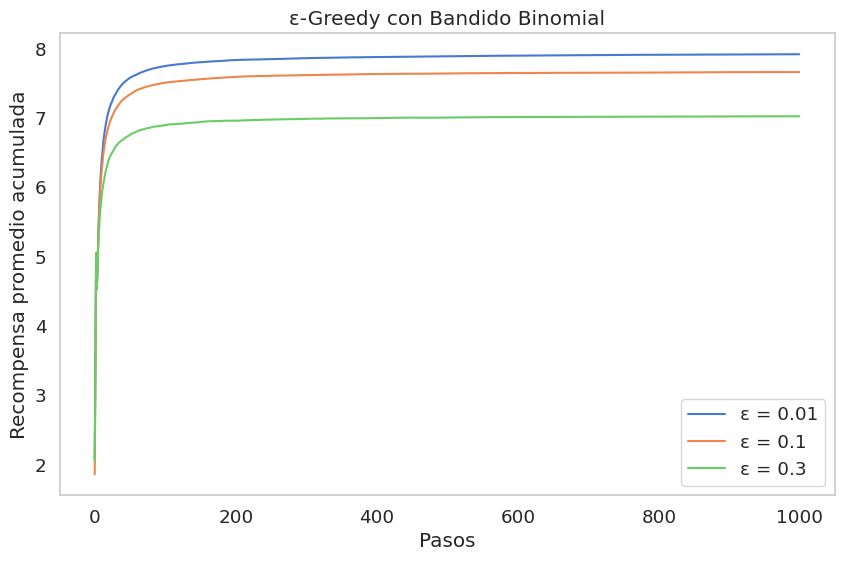

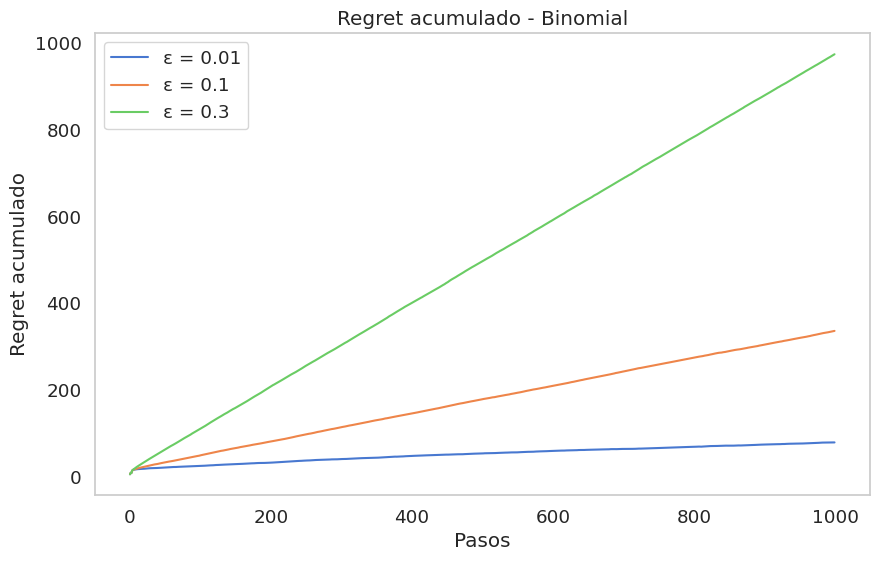

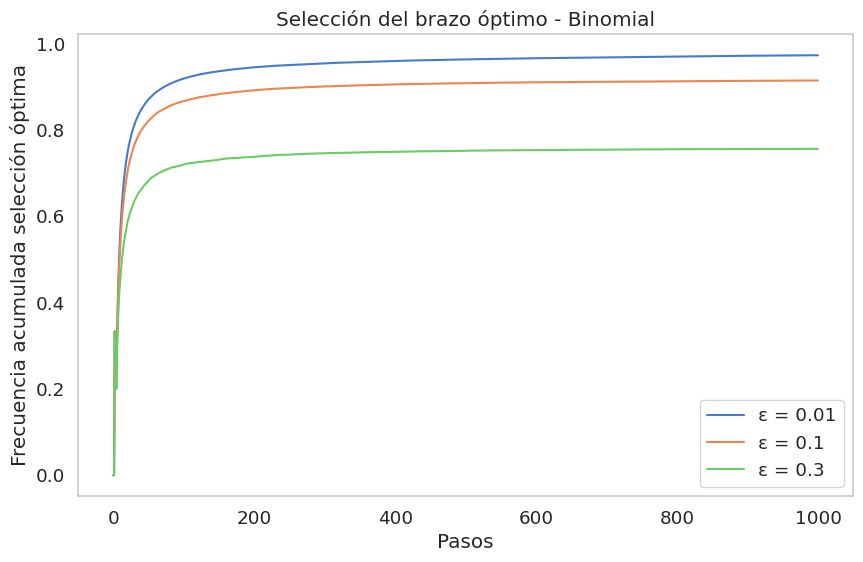

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1️⃣ ENTORNO BINOMIAL B(n, p)
# ==============================

class BinomialBandit:
    def __init__(self, n, probabilities):
        """
        n: número de ensayos por tirada
        probabilities: lista de p_i para cada brazo
        """
        self.n = n
        self.probabilities = np.array(probabilities)
        self.k = len(probabilities)
        self.optimal_arm = np.argmax(self.probabilities)
        self.optimal_mean = np.max(self.probabilities) * n

    def pull(self, arm):
        return np.random.binomial(self.n, self.probabilities[arm])


# ==============================
# 2️⃣ CLASE BASE
# ==============================

class Algorithm:
    def __init__(self, k):
        self.k = k
        self.counts = np.zeros(k)
        self.values = np.zeros(k)

    def update(self, chosen_arm, reward):
        self.counts[chosen_arm] += 1
        n = self.counts[chosen_arm]
        value = self.values[chosen_arm]
        self.values[chosen_arm] += (reward - value) / n


# ==============================
# 3️⃣ EPSILON-GREEDY
# ==============================

class EpsilonGreedy(Algorithm):

    def __init__(self, k, epsilon=0.1):
        assert 0 <= epsilon <= 1
        super().__init__(k)
        self.epsilon = epsilon

    def select_arm(self):
        # Asegurar que cada brazo se prueba al menos una vez
        for arm in range(self.k):
            if self.counts[arm] == 0:
                return arm

        if np.random.random() < self.epsilon:
            return np.random.choice(self.k)
        else:
            return np.argmax(self.values)


# ==============================
# 4️⃣ SIMULACIÓN
# ==============================

def run_experiment(algorithms, bandit, steps=1000, simulations=500):

    n_algorithms = len(algorithms)

    rewards = np.zeros((n_algorithms, steps))
    regret = np.zeros((n_algorithms, steps))
    optimal_selections = np.zeros((n_algorithms, steps))

    for s in range(simulations):

        alg_instances = [type(algo)(bandit.k, algo.epsilon) for algo in algorithms]

        for i, algo in enumerate(alg_instances):

            for t in range(steps):
                arm = algo.select_arm()
                reward = bandit.pull(arm)
                algo.update(arm, reward)

                rewards[i, t] += reward
                regret[i, t] += bandit.optimal_mean - reward

                if arm == bandit.optimal_arm:
                    optimal_selections[i, t] += 1

    rewards /= simulations
    regret /= simulations
    optimal_selections /= simulations

    return rewards, regret, optimal_selections


# ==============================
# 5️⃣ PARÁMETROS
# ==============================

k = 5
n = 10  # número de ensayos por tirada
probabilities = [0.2, 0.5, 0.8, 0.3, 0.6]  # brazo óptimo = índice 2
steps = 1000
simulations = 500

bandit = BinomialBandit(n, probabilities)

algorithms = [
    EpsilonGreedy(k, epsilon=0.01),
    EpsilonGreedy(k, epsilon=0.1),
    EpsilonGreedy(k, epsilon=0.3),
]

labels = ["ε = 0.01", "ε = 0.1", "ε = 0.3"]

rewards, regret, optimal_selections = run_experiment(
    algorithms, bandit, steps, simulations
)


# ==============================
# 6️⃣ GRÁFICAS
# ==============================

# 🔹 Recompensa promedio acumulada
plt.figure(figsize=(10,6))
for i in range(len(algorithms)):
    avg_reward = np.cumsum(rewards[i]) / np.arange(1, steps+1)
    plt.plot(avg_reward, label=labels[i])

plt.xlabel("Pasos")
plt.ylabel("Recompensa promedio acumulada")
plt.title("ε-Greedy con Bandido Binomial")
plt.legend()
plt.grid()
plt.show()


# 🔹 Regret acumulado
plt.figure(figsize=(10,6))
for i in range(len(algorithms)):
    cumulative_regret = np.cumsum(regret[i])
    plt.plot(cumulative_regret, label=labels[i])

plt.xlabel("Pasos")
plt.ylabel("Regret acumulado")
plt.title("Regret acumulado - Binomial")
plt.legend()
plt.grid()
plt.show()


# 🔹 Frecuencia selección óptima
plt.figure(figsize=(10,6))
for i in range(len(algorithms)):
    optimal_rate = np.cumsum(optimal_selections[i]) / np.arange(1, steps+1)
    plt.plot(optimal_rate, label=labels[i])

plt.xlabel("Pasos")
plt.ylabel("Frecuencia acumulada selección óptima")
plt.title("Selección del brazo óptimo - Binomial")
plt.legend()
plt.grid()
plt.show()

ε-Greedy con Normal — Experimentos con distintas desviaciones y número de brazos

✅ Normal con σ = 1

✅ Normal con σ = 50

✅ Normal con σ = 100

✅ k = 10, 20 o 100 brazos

✅ Comparar varios ε

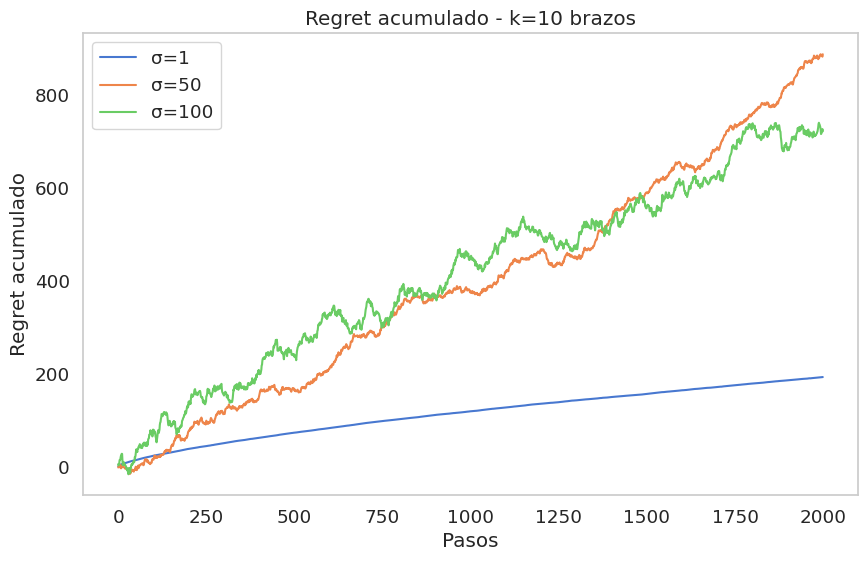

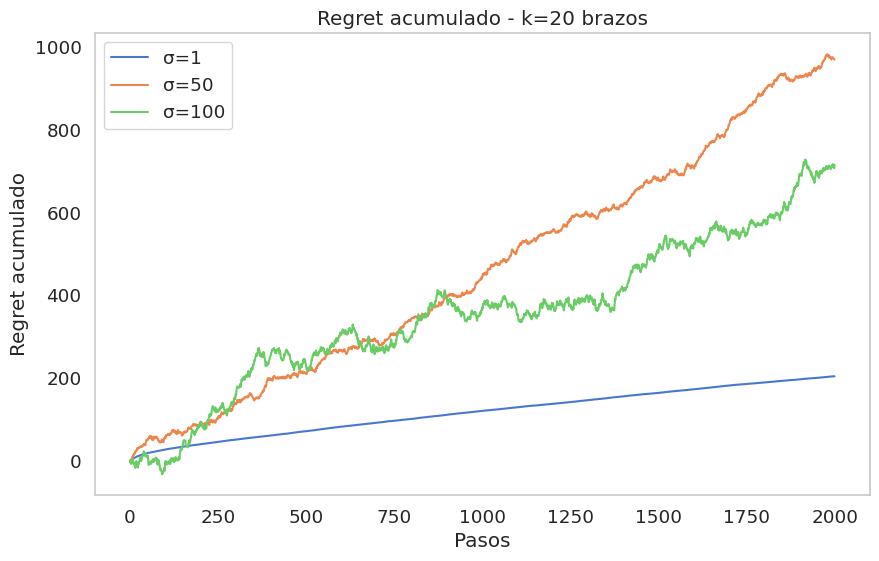

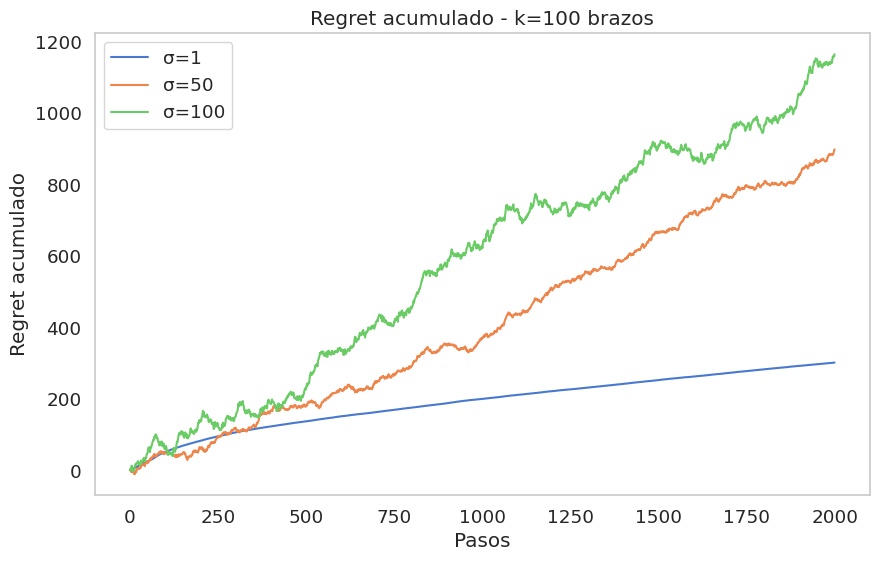

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# 1️⃣ ENTORNO NORMAL
# =====================================

class NormalBandit:
    def __init__(self, means, std=1):
        self.means = np.array(means)
        self.k = len(means)
        self.std = std
        self.optimal_arm = np.argmax(self.means)
        self.optimal_mean = np.max(self.means)

    def pull(self, arm):
        return np.random.normal(self.means[arm], self.std)


# =====================================
# 2️⃣ CLASE BASE
# =====================================

class Algorithm:
    def __init__(self, k):
        self.k = k
        self.counts = np.zeros(k)
        self.values = np.zeros(k)

    def update(self, chosen_arm, reward):
        self.counts[chosen_arm] += 1
        n = self.counts[chosen_arm]
        value = self.values[chosen_arm]
        self.values[chosen_arm] += (reward - value) / n


# =====================================
# 3️⃣ EPSILON-GREEDY
# =====================================

class EpsilonGreedy(Algorithm):

    def __init__(self, k, epsilon=0.1):
        super().__init__(k)
        self.epsilon = epsilon

    def select_arm(self):

        # Forzar prueba inicial de todos los brazos
        for arm in range(self.k):
            if self.counts[arm] == 0:
                return arm

        if np.random.random() < self.epsilon:
            return np.random.choice(self.k)
        else:
            return np.argmax(self.values)


# =====================================
# 4️⃣ EXPERIMENTO
# =====================================

def run_experiment(k=10, std=1, steps=2000, simulations=500, epsilon=0.1):

    # Medias aleatorias fijas para todos los ensayos
    means = np.random.uniform(0, 1, k)

    bandit = NormalBandit(means, std)
    regret = np.zeros(steps)

    for s in range(simulations):

        algo = EpsilonGreedy(k, epsilon)

        for t in range(steps):
            arm = algo.select_arm()
            reward = bandit.pull(arm)
            algo.update(arm, reward)

            regret[t] += bandit.optimal_mean - reward

    regret /= simulations
    return np.cumsum(regret)


# =====================================
# 5️⃣ ENSAYOS
# =====================================

steps = 2000
simulations = 500
epsilon = 0.1

# Cambia aquí número de brazos
k_values = [10, 20, 100]

# Cambia aquí desviaciones
std_values = [1, 50, 100]

for k in k_values:
    plt.figure(figsize=(10,6))

    for std in std_values:
        cumulative_regret = run_experiment(
            k=k,
            std=std,
            steps=steps,
            simulations=simulations,
            epsilon=epsilon
        )

        plt.plot(cumulative_regret, label=f"σ={std}")

    plt.title(f"Regret acumulado - k={k} brazos")
    plt.xlabel("Pasos")
    plt.ylabel("Regret acumulado")
    plt.legend()
    plt.grid()
    plt.show()

Distribución Bernoulli, estudiando:

✅ Diferente número de brazos: k = 10, 20, 100

✅ Mismas probabilidades base

✅ Comparar comportamiento del regret

✅ ε fijo (ε = 0, 0.01, 0.1)

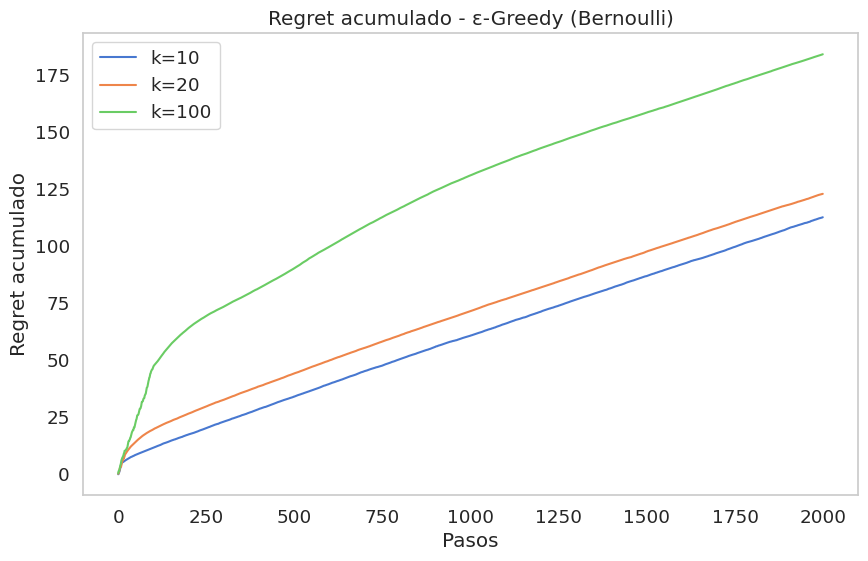

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# 1️⃣ ENTORNO BERNOULLI
# =====================================

class BernoulliBandit:
    def __init__(self, probabilities):
        self.probabilities = np.array(probabilities)
        self.k = len(probabilities)
        self.optimal_arm = np.argmax(self.probabilities)
        self.optimal_mean = np.max(self.probabilities)

    def pull(self, arm):
        return np.random.binomial(1, self.probabilities[arm])


# =====================================
# 2️⃣ CLASE BASE
# =====================================

class Algorithm:
    def __init__(self, k):
        self.k = k
        self.counts = np.zeros(k)
        self.values = np.zeros(k)

    def update(self, chosen_arm, reward):
        self.counts[chosen_arm] += 1
        n = self.counts[chosen_arm]
        value = self.values[chosen_arm]
        self.values[chosen_arm] += (reward - value) / n


# =====================================
# 3️⃣ EPSILON-GREEDY
# =====================================

class EpsilonGreedy(Algorithm):

    def __init__(self, k, epsilon=0.1):
        super().__init__(k)
        self.epsilon = epsilon

    def select_arm(self):

        # Asegurar que todos los brazos se prueban al menos una vez
        for arm in range(self.k):
            if self.counts[arm] == 0:
                return arm

        if np.random.random() < self.epsilon:
            return np.random.choice(self.k)
        else:
            return np.argmax(self.values)


# =====================================
# 4️⃣ EXPERIMENTO
# =====================================

def run_experiment(k=10, steps=2000, simulations=500, epsilon=0.1):

    # Generamos probabilidades aleatorias
    probabilities = np.random.uniform(0, 1, k)

    bandit = BernoulliBandit(probabilities)
    regret = np.zeros(steps)

    for s in range(simulations):

        algo = EpsilonGreedy(k, epsilon)

        for t in range(steps):
            arm = algo.select_arm()
            reward = bandit.pull(arm)
            algo.update(arm, reward)

            regret[t] += bandit.optimal_mean - reward

    regret /= simulations
    return np.cumsum(regret)


# =====================================
# 5️⃣ ENSAYOS
# =====================================

steps = 2000
simulations = 500
epsilon = 0.1

k_values = [10, 20, 100]

plt.figure(figsize=(10,6))

for k in k_values:
    cumulative_regret = run_experiment(
        k=k,
        steps=steps,
        simulations=simulations,
        epsilon=epsilon
    )
    plt.plot(cumulative_regret, label=f"k={k}")

plt.title("Regret acumulado - ε-Greedy (Bernoulli)")
plt.xlabel("Pasos")
plt.ylabel("Regret acumulado")
plt.legend()
plt.grid()
plt.show()

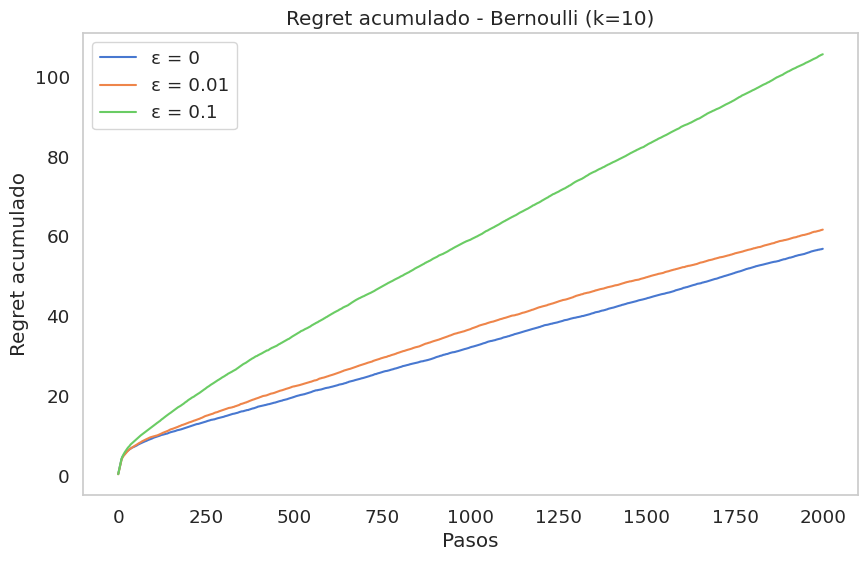

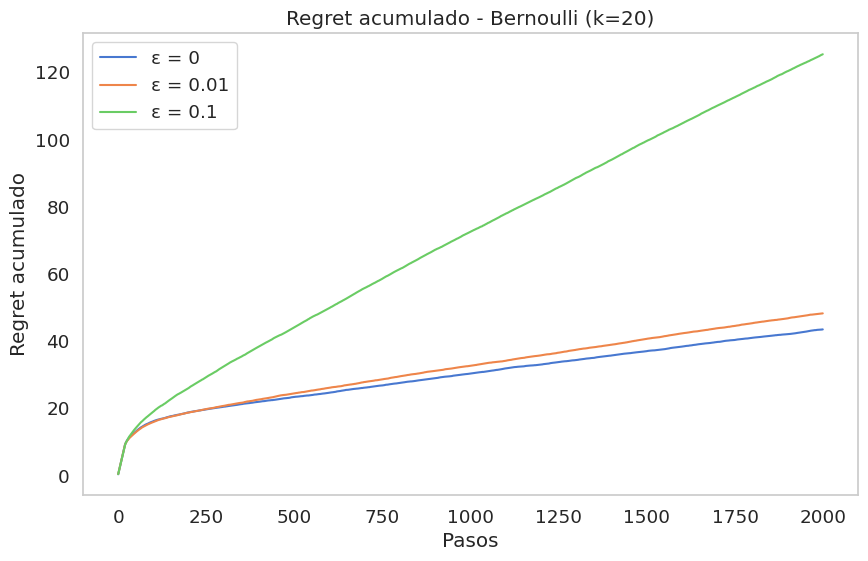

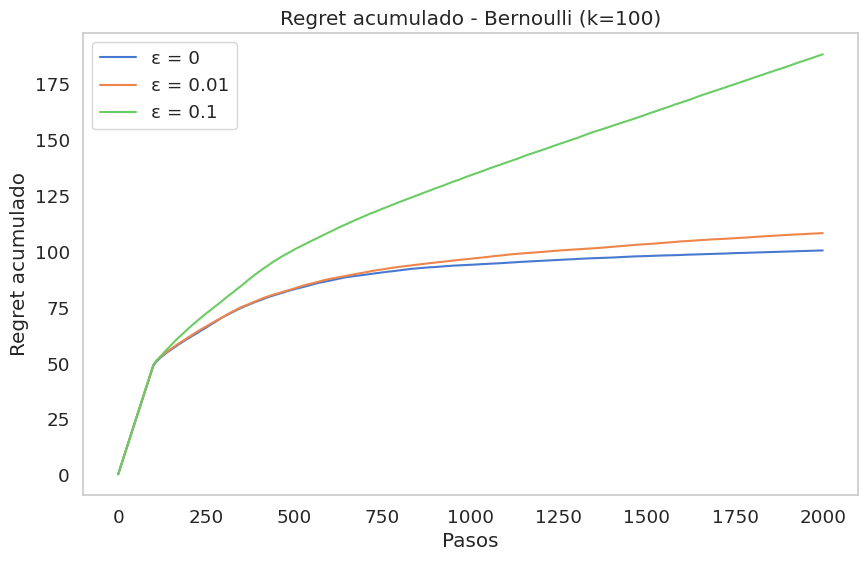

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# 1️⃣ ENTORNO BERNOULLI
# =====================================

class BernoulliBandit:
    def __init__(self, probabilities):
        self.probabilities = np.array(probabilities)
        self.k = len(probabilities)
        self.optimal_arm = np.argmax(self.probabilities)
        self.optimal_mean = np.max(self.probabilities)

    def pull(self, arm):
        return np.random.binomial(1, self.probabilities[arm])


# =====================================
# 2️⃣ CLASE BASE
# =====================================

class Algorithm:
    def __init__(self, k):
        self.k = k
        self.counts = np.zeros(k)
        self.values = np.zeros(k)

    def update(self, chosen_arm, reward):
        self.counts[chosen_arm] += 1
        n = self.counts[chosen_arm]
        value = self.values[chosen_arm]
        self.values[chosen_arm] += (reward - value) / n


# =====================================
# 3️⃣ EPSILON-GREEDY
# =====================================

class EpsilonGreedy(Algorithm):

    def __init__(self, k, epsilon=0.1):
        super().__init__(k)
        self.epsilon = epsilon

    def select_arm(self):

        # Forzar que todos los brazos se prueben al menos una vez
        for arm in range(self.k):
            if self.counts[arm] == 0:
                return arm

        if np.random.random() < self.epsilon:
            return np.random.choice(self.k)
        else:
            return np.argmax(self.values)


# =====================================
# 4️⃣ EXPERIMENTO
# =====================================

def run_experiment(k, epsilon, steps=2000, simulations=500):

    regret = np.zeros(steps)

    for s in range(simulations):

        probabilities = np.random.uniform(0, 1, k)
        bandit = BernoulliBandit(probabilities)
        algo = EpsilonGreedy(k, epsilon)

        for t in range(steps):
            arm = algo.select_arm()
            reward = bandit.pull(arm)
            algo.update(arm, reward)

            regret[t] += bandit.optimal_mean - reward

    regret /= simulations
    return np.cumsum(regret)


# =====================================
# 5️⃣ ENSAYOS
# =====================================

steps = 2000
simulations = 500

k_values = [10, 20, 100]
epsilon_values = [0, 0.01, 0.1]

for k in k_values:

    plt.figure(figsize=(10,6))

    for epsilon in epsilon_values:
        cumulative_regret = run_experiment(
            k=k,
            epsilon=epsilon,
            steps=steps,
            simulations=simulations
        )

        plt.plot(cumulative_regret, label=f"ε = {epsilon}")

    plt.title(f"Regret acumulado - Bernoulli (k={k})")
    plt.xlabel("Pasos")
    plt.ylabel("Regret acumulado")
    plt.legend()
    plt.grid()
    plt.show()

Distribución Binomial:

𝑅∼𝐵(𝑛,𝑝𝑖)R∼B(n,pi)

Aquí vamos a estudiar:

✅ Diferente número de brazos: k = 10, 20, 100

✅ Mismo número de ensayos n

✅ ε-greedy ε = 0, 0.01, 0.1

✅ Regret acumulado

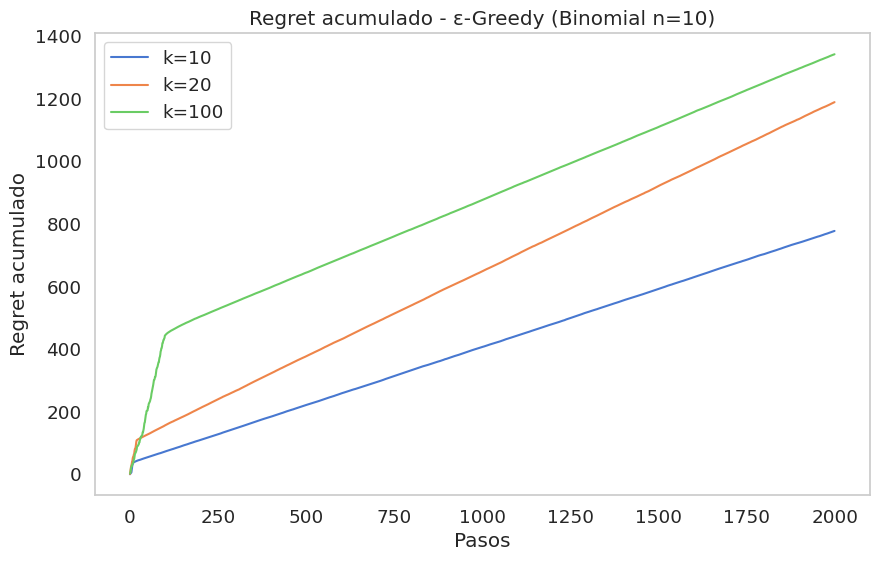

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# 1️⃣ ENTORNO BINOMIAL
# =====================================

class BinomialBandit:
    def __init__(self, n, probabilities):
        self.n = n
        self.probabilities = np.array(probabilities)
        self.k = len(probabilities)
        self.optimal_arm = np.argmax(self.probabilities)
        self.optimal_mean = np.max(self.probabilities) * n

    def pull(self, arm):
        return np.random.binomial(self.n, self.probabilities[arm])


# =====================================
# 2️⃣ CLASE BASE
# =====================================

class Algorithm:
    def __init__(self, k):
        self.k = k
        self.counts = np.zeros(k)
        self.values = np.zeros(k)

    def update(self, chosen_arm, reward):
        self.counts[chosen_arm] += 1
        n = self.counts[chosen_arm]
        value = self.values[chosen_arm]
        self.values[chosen_arm] += (reward - value) / n


# =====================================
# 3️⃣ EPSILON-GREEDY
# =====================================

class EpsilonGreedy(Algorithm):

    def __init__(self, k, epsilon=0.1):
        super().__init__(k)
        self.epsilon = epsilon

    def select_arm(self):

        # Probar cada brazo al menos una vez
        for arm in range(self.k):
            if self.counts[arm] == 0:
                return arm

        if np.random.random() < self.epsilon:
            return np.random.choice(self.k)
        else:
            return np.argmax(self.values)


# =====================================
# 4️⃣ EXPERIMENTO
# =====================================

def run_experiment(k=10, n=10, steps=2000, simulations=500, epsilon=0.1):

    # Probabilidades aleatorias
    probabilities = np.random.uniform(0, 1, k)

    bandit = BinomialBandit(n, probabilities)
    regret = np.zeros(steps)

    for s in range(simulations):

        algo = EpsilonGreedy(k, epsilon)

        for t in range(steps):
            arm = algo.select_arm()
            reward = bandit.pull(arm)
            algo.update(arm, reward)

            regret[t] += bandit.optimal_mean - reward

    regret /= simulations
    return np.cumsum(regret)


# =====================================
# 5️⃣ ENSAYOS
# =====================================

steps = 2000
simulations = 500
epsilon = 0.1
n = 10   # número de ensayos por tirada

k_values = [10, 20, 100]

plt.figure(figsize=(10,6))

for k in k_values:
    cumulative_regret = run_experiment(
        k=k,
        n=n,
        steps=steps,
        simulations=simulations,
        epsilon=epsilon
    )
    plt.plot(cumulative_regret, label=f"k={k}")

plt.title(f"Regret acumulado - ε-Greedy (Binomial n={n})")
plt.xlabel("Pasos")
plt.ylabel("Regret acumulado")
plt.legend()
plt.grid()
plt.show()

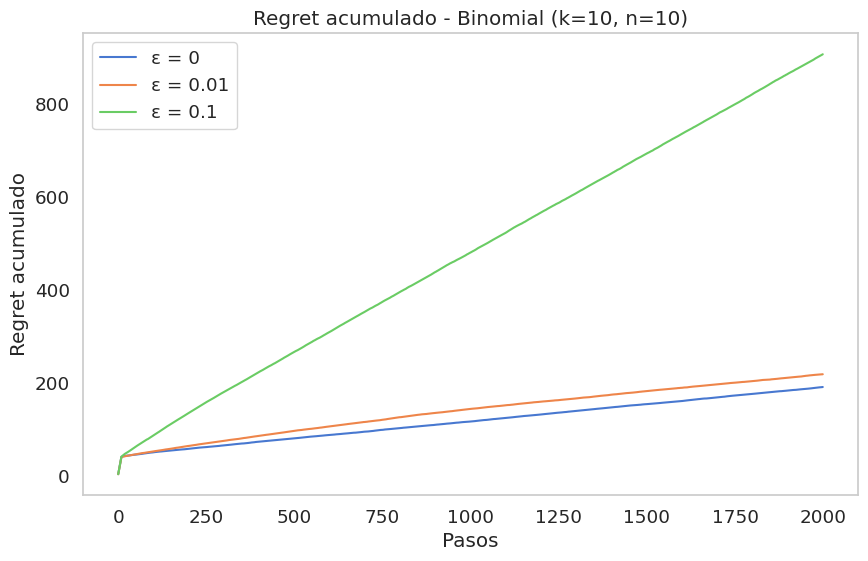

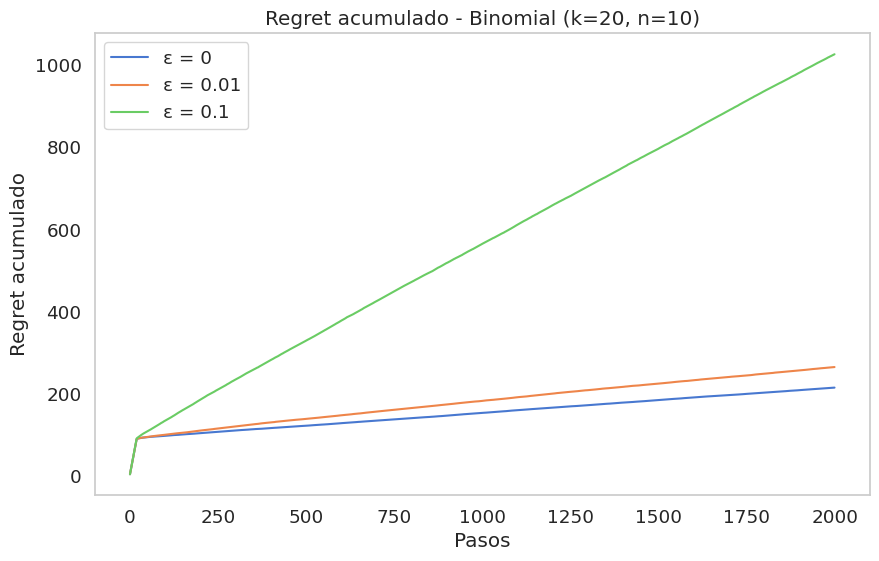

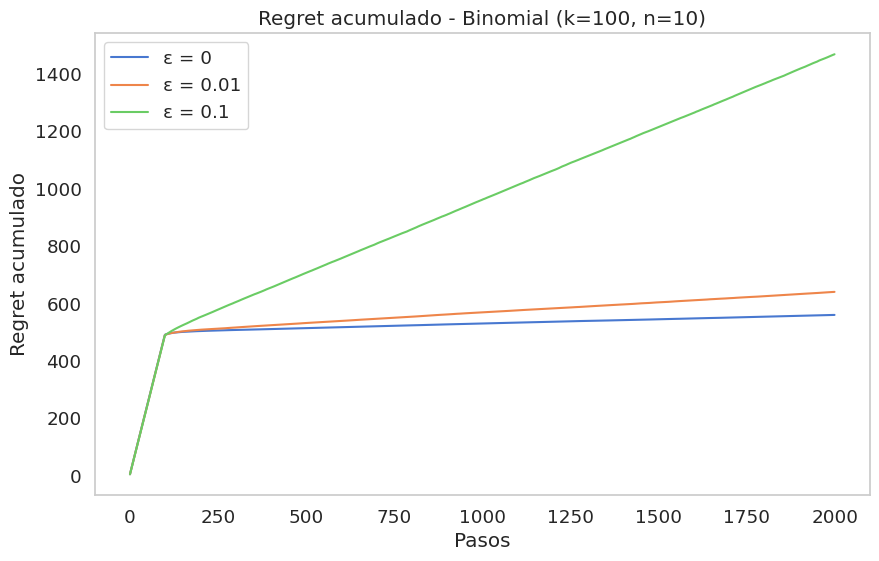

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# 1️⃣ ENTORNO BINOMIAL
# =====================================

class BinomialBandit:
    def __init__(self, n, probabilities):
        self.n = n
        self.probabilities = np.array(probabilities)
        self.k = len(probabilities)
        self.optimal_arm = np.argmax(self.probabilities)
        self.optimal_mean = np.max(self.probabilities) * n

    def pull(self, arm):
        return np.random.binomial(self.n, self.probabilities[arm])


# =====================================
# 2️⃣ CLASE BASE
# =====================================

class Algorithm:
    def __init__(self, k):
        self.k = k
        self.counts = np.zeros(k)
        self.values = np.zeros(k)

    def update(self, chosen_arm, reward):
        self.counts[chosen_arm] += 1
        n = self.counts[chosen_arm]
        value = self.values[chosen_arm]
        self.values[chosen_arm] += (reward - value) / n


# =====================================
# 3️⃣ EPSILON-GREEDY
# =====================================

class EpsilonGreedy(Algorithm):

    def __init__(self, k, epsilon=0.1):
        super().__init__(k)
        self.epsilon = epsilon

    def select_arm(self):

        # Asegurar que cada brazo se prueba al menos una vez
        for arm in range(self.k):
            if self.counts[arm] == 0:
                return arm

        if np.random.random() < self.epsilon:
            return np.random.choice(self.k)
        else:
            return np.argmax(self.values)


# =====================================
# 4️⃣ EXPERIMENTO
# =====================================

def run_experiment(k, n, epsilon, steps=2000, simulations=500):

    regret = np.zeros(steps)

    for s in range(simulations):

        probabilities = np.random.uniform(0, 1, k)
        bandit = BinomialBandit(n, probabilities)
        algo = EpsilonGreedy(k, epsilon)

        for t in range(steps):
            arm = algo.select_arm()
            reward = bandit.pull(arm)
            algo.update(arm, reward)

            regret[t] += bandit.optimal_mean - reward

    regret /= simulations
    return np.cumsum(regret)


# =====================================
# 5️⃣ ENSAYOS
# =====================================

steps = 2000
simulations = 500
n = 10   # mismo número de ensayos para todos

k_values = [10, 20, 100]
epsilon_values = [0, 0.01, 0.1]

for k in k_values:

    plt.figure(figsize=(10,6))

    for epsilon in epsilon_values:
        cumulative_regret = run_experiment(
            k=k,
            n=n,
            epsilon=epsilon,
            steps=steps,
            simulations=simulations
        )

        plt.plot(cumulative_regret, label=f"ε = {epsilon}")

    plt.title(f"Regret acumulado - Binomial (k={k}, n={n})")
    plt.xlabel("Pasos")
    plt.ylabel("Regret acumulado")
    plt.legend()
    plt.grid()
    plt.show()